In [1]:
import sys, os
import numpy as np
import pyshtools as pysh
import time
from scipy.integrate import lebedev_rule
from astropy.coordinates import spherical_to_cartesian, cartesian_to_spherical

from SpaceBalls.radiation_settings import get_ae_sh_maps_numpy_new
from SpaceBalls.sph_meshing import get_sphere_grid, lonlat_to_r, get_spherical_grid_cell_areas, get_reshaped_grid
from SpaceBalls.plotter import Plotter
from SpaceBalls.radiation_fluxes_preprocessing import compute_all_fluxes_at_altitude # that's for a full map
import config.constants as constants
from SpaceBalls.paths import CONFIG_DIR

lebedev_n_array = [41, 47, 53, 59, 65, 71, 77, 83,
                    89, 95, 101, 107, 113, 119, 125, 131] # 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 35,

n_points_lebedev = [590, 770, 974, 1202, 1454, 1730, 2030, 2354,
                    2702, 3074, 3470, 3890, 4334, 4802, 5294, 5810] # 6, 14, 26, 38, 50, 74, 86, 110, 146, 170, 194, 230, 266, 302, 350, 434,
                    

n_leb = len(lebedev_n_array)

Re = constants.earth_radius()
a_CS, e_CS = get_ae_sh_maps_numpy_new(mode='historic_SYN1deg', date='2019-01-01')
e_sh_coeffs = pysh.SHCoeffs.from_array(e_CS, normalization='unnorm')
tsi = 1400

def compute_flux_at_r_regular_toa_grid(r, toa_bin_size_deg):
    
    n_lon, n_lat = int(360/toa_bin_size_deg), int(180/toa_bin_size_deg)
    lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
    full_lon_vec, full_lat_vec, _ = get_reshaped_grid(lon_vec, lat_vec)
    grid_r_el = lonlat_to_r(lon_vec, lat_vec, 0, "spherical")
    area_elements = get_spherical_grid_cell_areas(lat_edges_vec, lon_edges_vec)
    expanded_e = e_sh_coeffs.expand(lat=full_lat_vec, lon=full_lon_vec)
    expanded_e = np.reshape(expanded_e, (n_lat, n_lon))
    #expanded_e = np.ones_like(area_elements)


    t1 = time.time()
    r_rel = r[None, None, :] - grid_r_el
    r_rel_norm = np.linalg.norm(r_rel, axis=2)
    u_rel = r_rel/r_rel_norm[:, :, None]

    rS_dot_r_rel = np.sum(r_rel*grid_r_el, axis=2)
    cos_alpha = rS_dot_r_rel / (Re * r_rel_norm)
    cos_alpha[cos_alpha<0] = 0
    n_points_in = np.count_nonzero(cos_alpha)

    #integral_surf = np.sum(area_elements * expanded_e * Fx) / np.sum(area_elements)

    kernel =  (1/np.pi) * cos_alpha[:,:,None] * (1/(r_rel_norm**2))[:,:,None] * u_rel
    map_to_integrate = expanded_e[:,:,None] * kernel
    F_outgoing = tsi * np.sum(map_to_integrate * area_elements[:,:,None], axis=(0,1))
    
    # all_F_outgoing =  expanded_e[:,:,None] * (1/np.pi) * area_elements[:,:,None] * cos_alpha[:,:,None] * (1/(r_rel_norm**2))[:,:,None] * u_rel
    #F_outgoing = np.sum(all_F_outgoing, axis=(0,1))
    t2 = time.time()

    return F_outgoing, t2-t1, n_points_in


def compute_flux_at_r_lebedev_toa_grid(r, lebedev_n):
    assert(lebedev_n in lebedev_n_array)
    r_el_leb, weights = lebedev_rule(lebedev_n)
    r_el_leb = np.transpose(r_el_leb) * Re
    (_, lat_leb, lon_leb) = cartesian_to_spherical(r_el_leb[:,0], r_el_leb[:,1], r_el_leb[:,2],)
    expanded_e = e_sh_coeffs.expand(lat=lat_leb.deg, lon=lon_leb.deg)
    #expanded_e = np.ones_like(weights)

    t1 = time.time()
    r_rel = r[None, :] - r_el_leb

    r_rel_norm = np.linalg.norm(r_rel, axis=1)
    u_rel = r_rel/r_rel_norm[:, None]

    rS_dot_r_rel = np.sum(r_rel*r_el_leb, axis=1)
    cos_alpha = rS_dot_r_rel / (Re * r_rel_norm)
    cos_alpha[cos_alpha<0] = 0
    n_points_in = np.count_nonzero(cos_alpha)
    
    kernel =  (1/np.pi) * cos_alpha[:,None] * (1/(r_rel_norm**2))[:,None] * u_rel
    map_to_integrate = expanded_e[:,None] * kernel

    F_outgoing = tsi * np.sum(weights[:,None]*map_to_integrate, axis=0) * Re**2
    t2 = time.time()

    return F_outgoing, t2-t1, n_points_in


def compute_flux_at_r_sd_toa_grid(r, sd_n):
    #assert(lebedev_n in lebedev_n_array)
    #r_el_leb, weights = lebedev_rule(lebedev_n)
    all_fnames = os.listdir(os.path.join(CONFIG_DIR, 'maths','spherical_designs_womersley'))
    fname = [f for f in all_fnames if f"ss{sd_n:03d}" in f]
    assert len(fname)==1
    r_el_leb = Re * np.loadtxt(os.path.join(CONFIG_DIR, 'maths','spherical_designs_womersley',fname[0]))
    n_points = np.shape(r_el_leb)[0]
    weights = np.ones(n_points) * (4 * np.pi * Re**2) / n_points

    #r_el_leb = np.transpose(r_el_leb) * Re
    (_, lat_leb, lon_leb) = cartesian_to_spherical(r_el_leb[:,0], r_el_leb[:,1], r_el_leb[:,2],)
    expanded_e = e_sh_coeffs.expand(lat=lat_leb.deg, lon=lon_leb.deg)
    #expanded_e = np.ones_like(weights)

    t1 = time.time()
    r_rel = r[None, :] - r_el_leb

    r_rel_norm = np.linalg.norm(r_rel, axis=1)
    u_rel = r_rel/r_rel_norm[:, None]

    rS_dot_r_rel = np.sum(r_rel*r_el_leb, axis=1)
    cos_alpha = rS_dot_r_rel / (Re * r_rel_norm)
    cos_alpha[cos_alpha<0] = 0
    n_points_in = np.count_nonzero(cos_alpha)
    
    
    kernel =  (1/np.pi) * cos_alpha[:,None] * (1/(r_rel_norm**2))[:,None] * u_rel
    map_to_integrate = expanded_e[:,None] * kernel

    F_outgoing = tsi * np.sum(weights[:,None]*map_to_integrate, axis=0)
    t2 = time.time()

    return F_outgoing, t2-t1, n_points, n_points_in


In [ ]:
    
r = np.array([1.15*Re,0,0])    # position vector of satellite
F_vec_leb, comp_time_leb = compute_flux_at_r_lebedev_toa_grid(r, 131)
print(F_vec_leb, comp_time_leb)

F_vec_sd, comp_time_sd, _ = compute_flux_at_r_sd_toa_grid(r, 231)
print(F_vec_sd, comp_time_sd)

F_vec, comp_time = compute_flux_at_r_regular_toa_grid(r, 0.5)
print(F_vec, comp_time)
#print(comp_time/comp_time_leb)

Computing convergence for 1500 km
25
27
29
31
33
35
37
39
41
43
45
47
49
51
53
55
57
59
61
63
65
67
69
71
73
75
77
79
81
83
85
87
89
91
93
95
97
99
101
103
105
107
109
111
113
115
117
119
121
123
125
127
129
131
133
135
137
139
141
143
145
147
149
151
153
155
157
159
161
163
165
167
169
171
173
175
177
179
181
183
185
187
189
191
193
195
197
199
201
203
205
207
209
211
213
215
217
219
221
223
225
227
229
231
233
235
237
239
241
243
245
247
249
251
253
255
257
259
261
263
265
267
269
271
273
275
277
279
281
283
285
287
289
291
293
295
297
299
301
303
305
307
309
311
313
315
317
319
321
323
325


/tmp/ipykernel_1510894/2547640151.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_top_2 = ax.secondary_xaxis('top', functions=(lambda x:np.sqrt(180*360/x), lambda x:180*360/(x**2)))


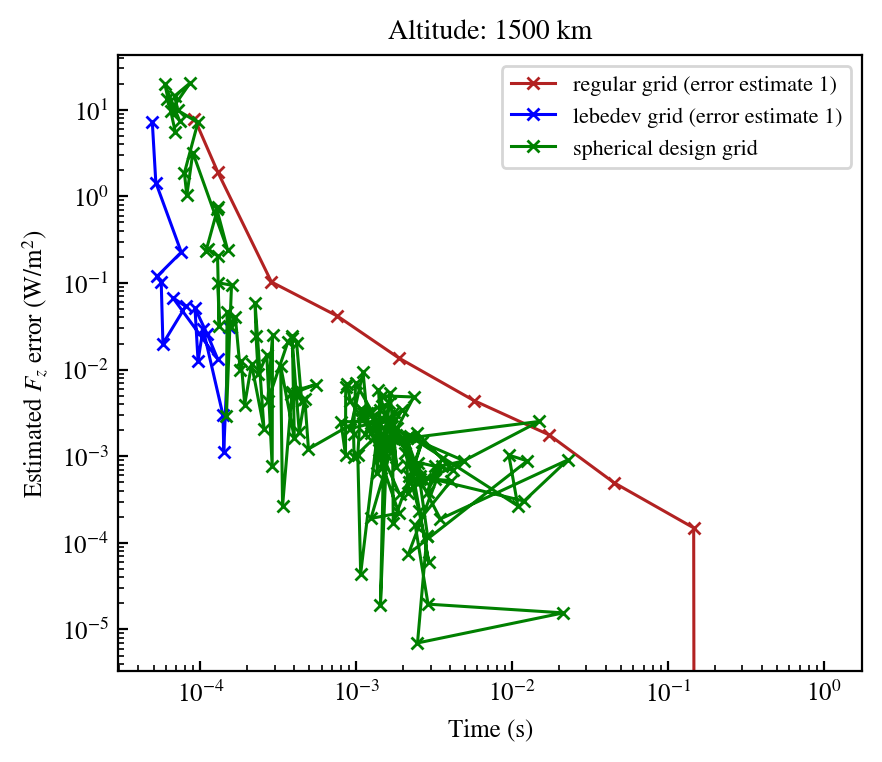

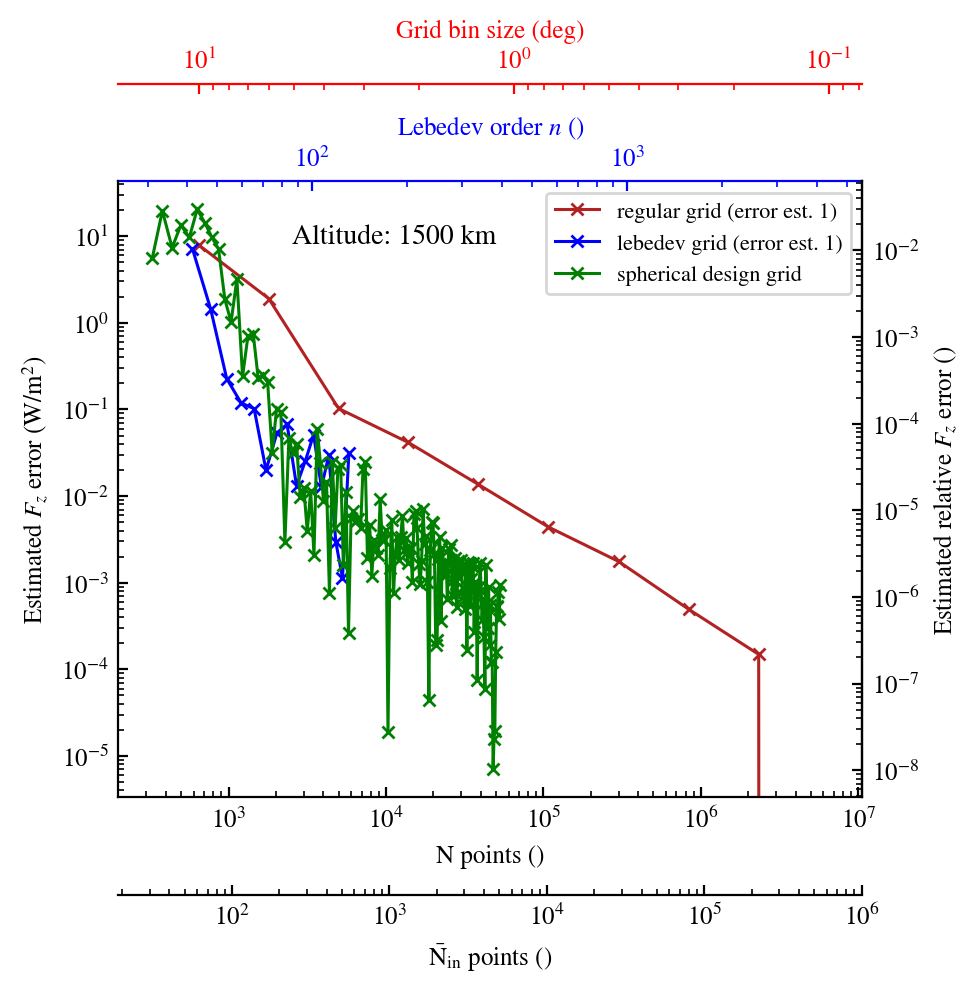

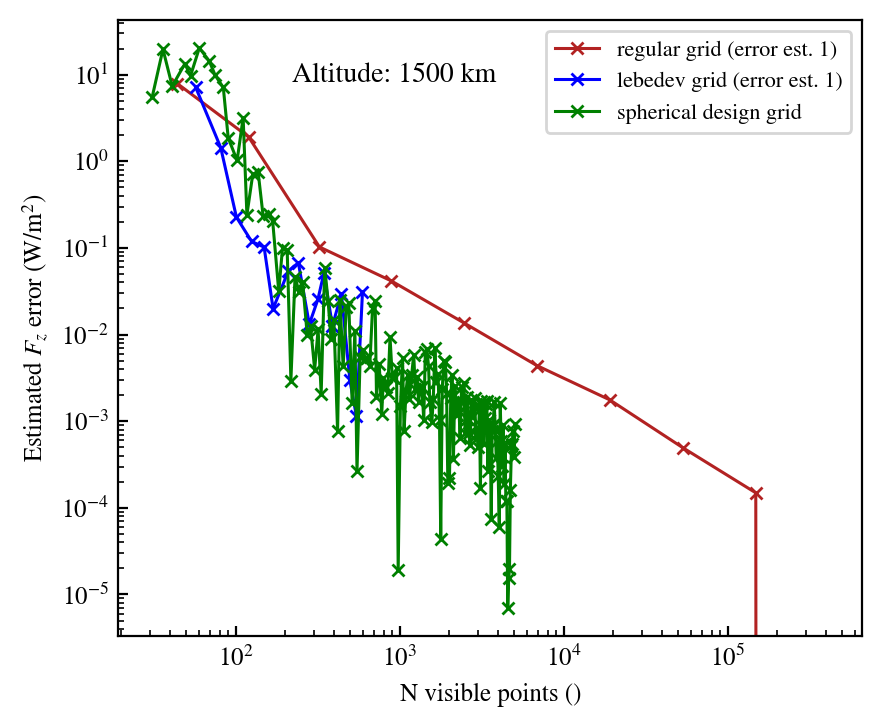

In [2]:
alt_array = [1500]

for alt in alt_array:
    print(f"Computing convergence for {alt} km")
    z = Re + alt
    r = np.array([z, 0, 0])    # position vector of satellite
    j=0

    n = 10
    deg_sizes = np.logspace(-1, 1, n)
    all_F = [None]*n
    times = [None]*n
    n_points_array = [None]*n
    n_points_in_array = [None]*n

    for i, deg_size in enumerate(deg_sizes):
        n_points_array[i] = int(360/deg_size) * int(180/deg_size)
        F_vec, comp_time, n_in = compute_flux_at_r_regular_toa_grid(r, deg_size)
        all_F[i] = F_vec
        times[i] = comp_time
        n_points_in_array[i] = n_in

    all_F = np.array(all_F)

    all_F_leb = [None]*n_leb
    times_leb = [None]*n_leb
    n_points_in_leb = [None]*n_leb

    for i, n in enumerate(lebedev_n_array[:(n_leb+1)]):
        F_vec, comp_time, n_in = compute_flux_at_r_lebedev_toa_grid(r, n)
        all_F_leb[i] = F_vec
        times_leb[i] = comp_time
        n_points_in_leb[i] = n_in


    all_F_leb = np.array(all_F_leb)

    all_F_sd = []
    times_sd = []
    n_points_sd = []
    n_points_in_sd = []

    for i in range(25, 325 + 1, 2):
        print(i)
        F_vec, comp_time, n_points, n_in = compute_flux_at_r_sd_toa_grid(r, i)
        all_F_sd.append(F_vec)
        times_sd.append(comp_time)
        n_points_sd.append(n_points)
        n_points_in_sd.append(n_in)

    all_F_sd = np.array(all_F_sd)
    n_points_sd = np.array(n_points_sd)

    errors_grid_1 = np.abs(all_F - all_F[0]) # all_F_sd[-1]
    #errors_grid_2 = np.abs(all_F - all_F[0])

    errors_leb_1 = np.abs(all_F_leb - all_F[0])
    #errors_leb_2 = np.abs(all_F_leb - all_F[0])

    errors_sd = np.abs(all_F_sd  - all_F[0])


    #print(errors_leb_1[:,2])


    Plotter.plot_convergence([times, times_leb, times_sd], 
                                    {'regular grid (error estimate 1)': errors_grid_1[:,j],
                                    #'regular grid (error estimate 2)': errors_grid_2[:,2],
                                    'lebedev grid (error estimate 1)': errors_leb_1[:,j],
                                    #'lebedev grid (error estimate 2)': errors_leb_2[:,2]}, 
                                    'spherical design grid': errors_sd[:,j] },
                                    xlabel='Time (s)', ylabel='Estimated $F_z$ error (W/m$^2$)', 
                                    f_width=1.2, f_height=1, cols=['firebrick','b','green'],
                                    title=f"Altitude: {alt} km")


    fig, ax = Plotter.plot_convergence([n_points_array, n_points_lebedev, n_points_sd], 
                            {       'regular grid (error est. 1)': errors_grid_1[:,j],
                                    #'regular grid (error est. 2)': errors_grid_2[:,2],
                                    'lebedev grid (error est. 1)': errors_leb_1[:,j],
                                    #'lebedev grid (error est. 2)': errors_leb_2[:,2]},
                                    'spherical design grid': errors_sd[:,j] },
                                    xlabel='N points ()', ylabel='Estimated $F_z$ error (W/m$^2$)', 
                                    f_width=1.2, f_height=1, cols=['firebrick','b','green'],
                                    title=f"Altitude: {alt} km", title_loc="inside")
    
    N_to_Nin_fact = 0.5 * (alt / (Re+alt))
    ax_bottom2 = ax.secondary_xaxis('bottom', functions=(lambda x: x*N_to_Nin_fact, lambda x: x/N_to_Nin_fact))
    ax_bottom2.spines['bottom'].set_position(('outward', 35))
    ax_bottom2.set_xlabel(r'$\mathrm{\bar N_{in}}$ points ()', fontsize=9)

    ax.spines['top'].set_visible(False)

    ax_top_1 = ax.secondary_xaxis('top', functions=(lambda x:(x/0.34)**0.5, lambda x: 0.34*x**2))
    ax_top_1.set_xlabel('Lebedev order $n$ ()', color='blue', fontsize=9)
    ax_top_1.spines['top'].set_color('blue')
    ax_top_1.tick_params(axis='x', colors='blue', which='both')

    ax_top_2 = ax.secondary_xaxis('top', functions=(lambda x:np.sqrt(180*360/x), lambda x:180*360/(x**2)))
    ax_top_2.set_xlabel('Grid bin size (deg)', color='red', fontsize=9)
    ax_top_2.spines['top'].set_color('red')
    ax_top_2.tick_params(axis='x', colors='red', which='both')
    ax_top_2.spines['top'].set_position(('outward', 35))

    ax_right = ax.secondary_yaxis('right', functions=(lambda x: x/all_F_leb[-1][j], lambda x: x*all_F_leb[-1][j]))
    ax_right.set_ylabel('Estimated relative $F_z$ error ()', fontsize=9)


    fig


    fig, ax = Plotter.plot_convergence([n_points_in_array, n_points_in_leb, n_points_in_sd], 
                            {       'regular grid (error est. 1)': errors_grid_1[:,j],
                                    #'regular grid (error est. 2)': errors_grid_2[:,2],
                                    'lebedev grid (error est. 1)': errors_leb_1[:,j],
                                    #'lebedev grid (error est. 2)': errors_leb_2[:,2]},
                                    'spherical design grid': errors_sd[:,j] },
                                    xlabel='N visible points ()', ylabel='Estimated $F_z$ error (W/m$^2$)', 
                                    f_width=1.2, f_height=1, cols=['firebrick','b','green'],
                                    title=f"Altitude: {alt} km", title_loc="inside")

#Plotter.plot_convergence(deg_sizes, errors[:,2], xlabel='Grid bin size (deg)', ylabel='Estimated $F_z$ error (W/m$^2$)', f_width=1.5)
#Plotter.plot_convergence(n_points_array, errors[:,2], xlabel='N points ()', ylabel='Estimated $F_z$ error (W/m$^2$)', f_width=1.5)


#F_vec, comp_time = compute_flux_at_r_regular_toa_grid(r, 3)
#print(F_vec, comp_time)

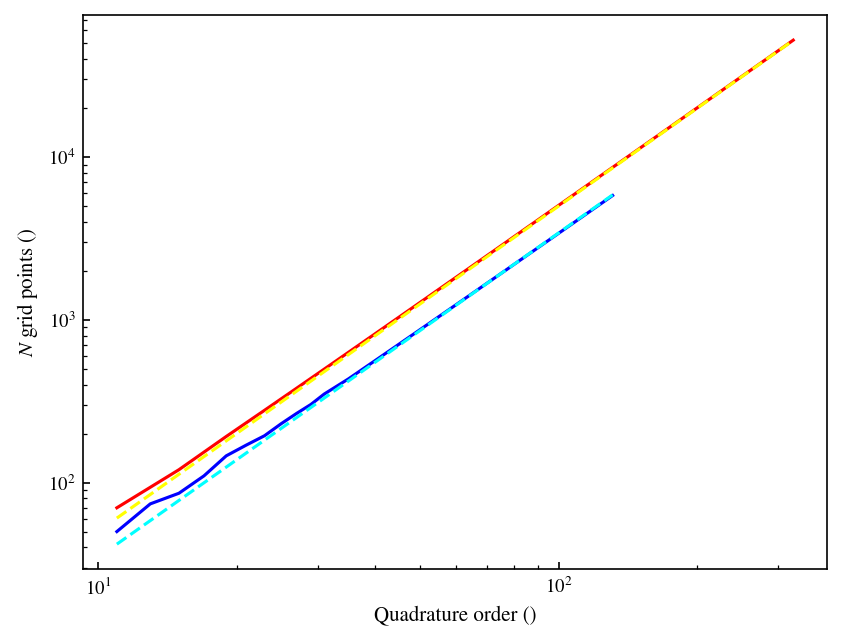

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from SpaceBalls.sph_meshing import QuadratureGrid
from SpaceBalls.plotter import Plotter

lebedev_n_array = [11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 35,
                   41, 47, 53, 59, 65, 71, 77, 83,
                    89, 95, 101, 107, 113, 119, 125, 131]
lebedev_grids = [QuadratureGrid(0, order=o) for o in lebedev_n_array]
n_points_lebedev = np.array([grid.n_points for grid in lebedev_grids])

womersley_n_array = np.arange(11, 325, 4)
womersley_grids = [QuadratureGrid(0, order=o, default_womersley=True) for o in womersley_n_array]
n_points_womersley = np.array([grid.n_points for grid in womersley_grids])

plt.loglog(lebedev_n_array, n_points_lebedev, color='blue')
plt.loglog(lebedev_n_array, 0.35*(np.array(lebedev_n_array))**(1.995), color='cyan', linestyle='--')

plt.loglog(womersley_n_array, n_points_womersley, color='red')
plt.plot(womersley_n_array, 0.5*(np.array(womersley_n_array))**2, color='yellow', linestyle='--')

plt.xlabel('Quadrature order ()')
plt.ylabel('$N$ grid points ()')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import lebedev_rule

# Create sphere
r = 6378
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = r * np.outer(np.cos(u), np.sin(v))
y = r * np.outer(np.sin(u), np.sin(v))
z = r * np.outer(np.ones_like(u), np.cos(v))

# Example points (Nx3 array)
points, weights = lebedev_rule(9)
points = np.transpose(points) * 6378


# Target point
target_point = np.array([0.0, 0.0, 1.5*6378])

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Sphere
ax.plot_surface(x, y, z,
                color='gray',
                alpha=0.3,
                edgecolor='none')

# Scatter points
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='red', s=20)

# Target point
ax.scatter(target_point[0], target_point[1], target_point[2],
           color='blue', s=20)

# Lines from each point to target
for p in points:
    ax.plot([p[0], target_point[0]],
            [p[1], target_point[1]],
            [p[2], target_point[2]],
            color='black', linewidth=1)

# Aspect ratio
ax.set_box_aspect([1, 1, 1.4])

ax.legend()
plt.show()

In [ ]:

# n_lon, n_lat = 360*3, 180*3
# lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
# grid_r_el = lonlat_to_r(lon_vec, lat_vec, 0, "spherical")
# 
# r = np.array([0,3*Re, 0,2*Re, 1.1*Re])    # position vector of satellite
# r_rel = r[None,None,:]- grid_r_el
# r_rel_norm = np.linalg.norm(r_rel, axis=2)
# u_rel = r_rel/r_rel_norm[:,:,None]
# 
# rS_dot_r_rel = np.sum(r_rel*grid_r_el, axis=2)
# 
# cos_alpha = rS_dot_r_rel / (Re * r_rel_norm)
# cos_tilde_alpha = 0.5*cos_alpha + 0.5 * np.sqrt(cos_alpha**2)
# 
# Plotter.plot_geo_data(cos_alpha, lon_edges_vec, lat_edges_vec, 'cos alpha')
# Plotter.plot_geo_data(cos_tilde_alpha, lon_edges_vec, lat_edges_vec, 'cos tilde alpha')
# 
# Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,0], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_x')
# Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,1], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_y')
# Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,2], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_z')


In [ ]:

from SpaceBalls.radiation_settings import get_ae_sh_maps_numpy_new
full_lon_vec, full_lat_vec, _ = get_reshaped_grid(lon_vec, lat_vec)

a_CS, e_CS = get_ae_sh_maps_numpy_new(mode='historic_SYN1deg', date='2018-01-01')
e_sh_coeffs = pysh.SHCoeffs.from_array(e_CS, normalization='unnorm')
expanded_e = e_sh_coeffs.expand(lat=full_lat_vec, lon=full_lon_vec)
expanded_e = np.reshape(expanded_e, (n_lat, n_lon))